In [1]:
!pip install pandas openpyxl scikit-learn matplotlib seaborn nltk -q

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [3]:
file_path = "/content/sector_data_annotation_TA.xlsx"
df = pd.read_excel(file_path, sheet_name=0)
df.head()

,Debate ID,Sitting Date,Debate Title,Speaker Turn 1 (opening — first speaker),Speaker Turn 2 (second speaker),★ SECTOR LABEL,★ CONFIDENCE,Is Overlap?,Labeller,Notes / Flags,Row #,Unnamed: 11,Remaining,NaN
0,D001,14-10-2025,Approval Process for Requests for Air-conditio...,asked the Minister for National Development (a...,"As of August 2025, about 7,000 public rental f...",Housing & Property,HIGH,NaN,NaN,NaN,1,NaN,── SECTOR COUNTS ──,NaN
1,D002,04-11-2025,Data on Out-of-Pocket Spending for Chronic Dis...,asked the Coordinating Minister for Social Pol...,The Ministry of Health (MOH) does not have rea...,Healthcare,HIGH,NaN,NaN,NaN,2,NaN,Healthcare,49.0
2,D003,04-02-2026,Discrepancies in Immigration Entry and Exit Re...,asked the Coordinating Minister for National S...,Based on the Immigration and Checkpoints Autho...,Defence & Home Affairs,HIGH,NaN,NaN,NaN,3,NaN,Education,40.0
3,D004,03-02-2026,Implications for Singapore from Disputes over ...,asked the Minister for Foreign Affairs what ar...,asked the Minister for Foreign Affairs (a) wha...,Defence & Home Affairs,MEDIUM,NaN,NaN,Foreign Affairs,4,NaN,Labour & Workforce,69.0
4,D005,14-10-2025,Evaluating Risky and Ineffective Airdrops of H...,asked the Coordinating Minister for Public Ser...,The preferred and most effective model of huma...,Defence & Home Affairs,MEDIUM,NaN,NaN,Foreign Affairs,5,NaN,Housing & Property,39.0


In [4]:
print(df.columns.tolist())

['Debate ID', 'Sitting Date', 'Debate Title', 'Speaker Turn 1 (opening — first speaker)', 'Speaker Turn 2 (second speaker)', '★ SECTOR LABEL', '★ CONFIDENCE', 'Is Overlap?', 'Labeller', 'Notes / Flags', 'Row #', 'Unnamed: 11', 'Remaining', nan]


In [5]:
renaming_map = {
    "Debate ID": "debate_id",
    "Sitting Date": "sitting_date",
    "Debate Title": "title",
    "Speaker Turn 1 (opening — first speaker)": "turn1",
    "Speaker Turn 2 (second speaker)": "turn2",
    "★ SECTOR LABEL": "sector_label",
    "★ CONFIDENCE": "confidence"
}

df = df.rename(columns=renaming_map)


In [6]:
df = df[["debate_id", "title", "turn1", "turn2", "sector_label", "confidence"]]
df.head()

,debate_id,title,turn1,turn2,sector_label,confidence
0,D001,Approval Process for Requests for Air-conditio...,asked the Minister for National Development (a...,"As of August 2025, about 7,000 public rental f...",Housing & Property,HIGH
1,D002,Data on Out-of-Pocket Spending for Chronic Dis...,asked the Coordinating Minister for Social Pol...,The Ministry of Health (MOH) does not have rea...,Healthcare,HIGH
2,D003,Discrepancies in Immigration Entry and Exit Re...,asked the Coordinating Minister for National S...,Based on the Immigration and Checkpoints Autho...,Defence & Home Affairs,HIGH
3,D004,Implications for Singapore from Disputes over ...,asked the Minister for Foreign Affairs what ar...,asked the Minister for Foreign Affairs (a) wha...,Defence & Home Affairs,MEDIUM
4,D005,Evaluating Risky and Ineffective Airdrops of H...,asked the Coordinating Minister for Public Ser...,The preferred and most effective model of huma...,Defence & Home Affairs,MEDIUM


In [7]:
df = df.dropna(subset=["sector_label"])

In [8]:
for col in ["title", "turn1", "turn2"]:
    df[col] = df[col].fillna("").astype(str)

In [9]:
df["sector_label"] = df["sector_label"].str.strip()
df["confidence"] = df["confidence"].astype(str).str.strip().str.upper()

In [10]:
df["combined_text"] = (
    df["title"] + " [SEP] " + df["turn1"] + " [SEP] " + df["turn2"]
)

In [11]:
print(df.loc[0, "combined_text"][:1000])

Approval Process for Requests for Air-conditioners to be Installed in HDB Rental Flats [SEP] asked the Minister for National Development (a) of the HDB public rental flats that are occupied, how many are currently approved to have air-conditioning units installed; (b) what are the common grounds on which such requests have been approved; and (c) what is the average waiting time for HDB to approve a rental flat tenant's request for air-conditioning installation. [SEP] As of August 2025, about 7,000 public rental flats had air conditioners installed. The Housing and Development Board will take into consideration tenants' circumstances, including medical grounds, in assessing each application. Approvals for air conditioner installation are usually issued within two weeks, if the proposed installation complies with the technical guidelines.


In [ ]:
export_df = df[[
    "debate_id", "title", "turn1", "turn2",
    "sector_label", "confidence", "combined_text"
]].copy()

export_df.to_csv("sector_training_data.csv", index=False)

In [12]:
print(df["sector_label"].value_counts())

sector_label
Labour & Workforce        69
Transport                 67
Healthcare                49
Social & Family Policy    43
Environment               42
Education                 40
Housing & Property        39
Defence & Home Affairs    22
Other / Cross-cutting     15
Digital Economy & Tech    10
Financial Services         9
Name: count, dtype: int64


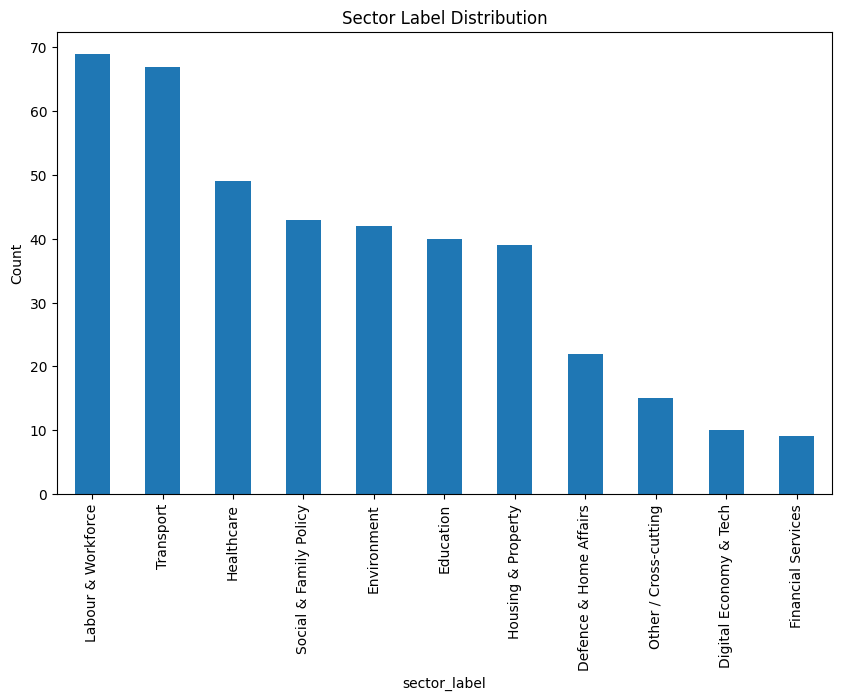

In [ ]:
plt.figure(figsize=(10,6))
df["sector_label"].value_counts().plot(kind="bar")
plt.title("Sector Label Distribution")
plt.ylabel("Count")
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
df["confidence_label"].value_counts().plot(kind="bar")
plt.title("Confidence Label Distribution")
plt.ylabel("Count")
plt.show()

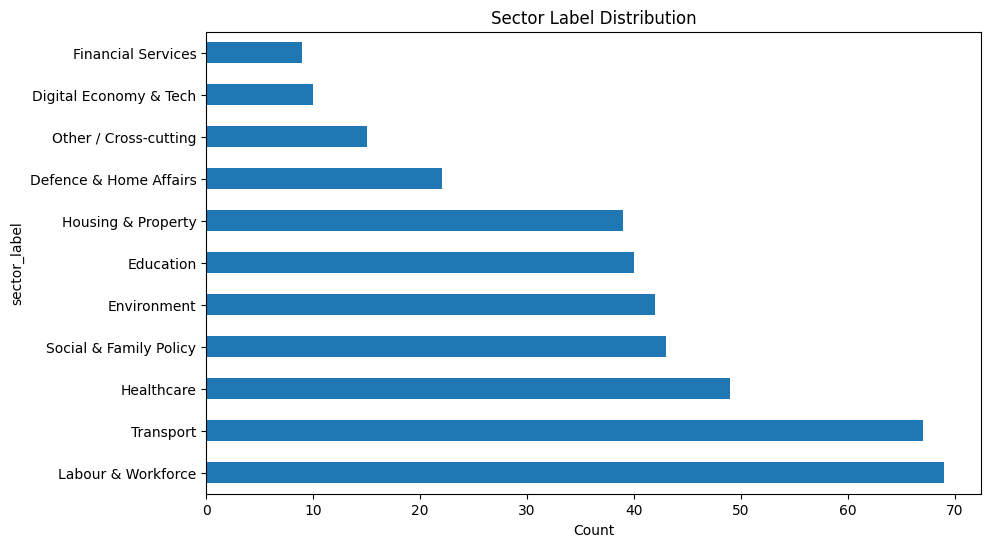

In [ ]:
plt.figure(figsize=(10,6))
df["sector_label"].value_counts().plot(kind="barh")
plt.title("Sector Label Distribution")
plt.xlabel("Count")
plt.show()

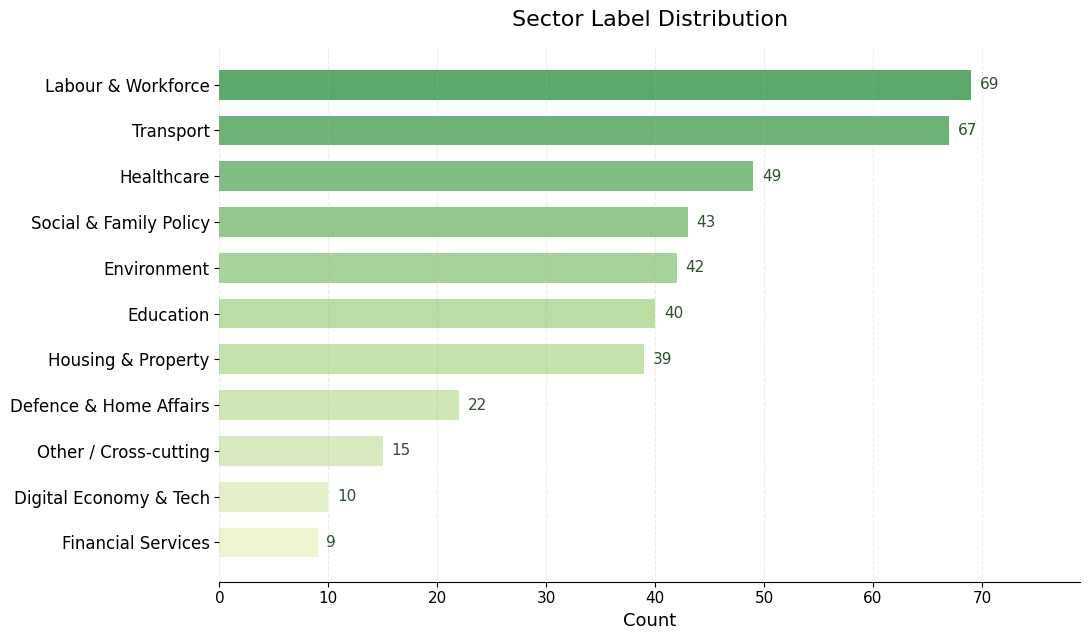

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 先按从少到多排序
counts = df["sector_label"].value_counts().sort_values(ascending=True)

# 自定义柔和渐变绿色
soft_green_cmap = LinearSegmentedColormap.from_list(
    "soft_green",
    ["#eef5d0", "#b9dda3", "#5ca96b"]   # 浅 -> 中 -> 深
)

# 生成渐变颜色
colors = soft_green_cmap(np.linspace(0, 1, len(counts)))

# 作图
fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.barh(counts.index, counts.values, color=colors, edgecolor="none", height=0.65)

# 标题和坐标轴
ax.set_title("Sector Label Distribution", fontsize=16, pad=14)
ax.set_xlabel("Count", fontsize=13)
ax.set_ylabel("")

# y轴字体（sector 名称）变大
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=11)

# 在每个 bar 后面标数值
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.8,                          # 数值放在 bar 后面
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=11,
        color="#2f4f2f"
    )

# 美化
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# 给右侧数值留空间
ax.set_xlim(0, counts.max() + 10)

plt.tight_layout()
plt.show()

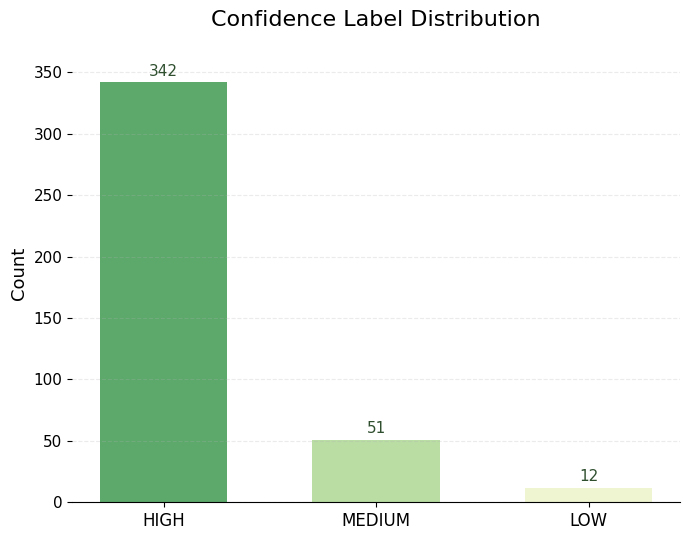

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 固定顺序
confidence_order = ["HIGH", "MEDIUM", "LOW"]

# 统计数量并按顺序排列
counts_conf = (
    df["confidence"]
    .value_counts()
    .reindex(confidence_order)
)

# 柔和绿色配色（浅 -> 中 -> 深）
colors = ["#5ca96b", "#b9dda3", "#eef5d0"]

# 作图
fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ax.bar(counts_conf.index, counts_conf.values, color=colors, edgecolor="none", width=0.6)

# 标题和坐标轴
ax.set_title("Confidence Label Distribution", fontsize=16, pad=14)
ax.set_xlabel("")
ax.set_ylabel("Count", fontsize=13)

# 字体大小
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=11)

# 在 bar 上方标数值
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 3,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#2f4f2f"
    )

# 美化
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# 给顶部数值留空间
ax.set_ylim(0, counts_conf.max() + 30)

plt.tight_layout()
plt.show()

In [15]:
X = df["combined_text"]
y = df["sector_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
sector_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95
    )),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        multi_class="auto"
    ))
])

In [17]:
sector_clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    multi_class='auto'))])

In [18]:
y_pred = sector_clf.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

Accuracy: 0.7901


In [ ]:
f1 = f1_score(y_test, y_pred, average="macro")
print("Macro F1:", round(f1, 4))

Macro F1: 0.692


In [ ]:
print(classification_report(y_test, y_pred))

                        precision    recall  f1-score   support

Defence & Home Affairs       1.00      0.75      0.86         4
Digital Economy & Tech       0.00      0.00      0.00         2
             Education       0.88      0.88      0.88         8
           Environment       0.70      0.88      0.78         8
    Financial Services       1.00      0.50      0.67         2
            Healthcare       0.91      1.00      0.95        10
    Housing & Property       0.86      0.75      0.80         8
    Labour & Workforce       0.90      0.64      0.75        14
 Other / Cross-cutting       0.50      0.33      0.40         3
Social & Family Policy       0.54      0.78      0.64         9
             Transport       0.81      1.00      0.90        13

              accuracy                           0.79        81
             macro avg       0.74      0.68      0.69        81
          weighted avg       0.79      0.79      0.78        81



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


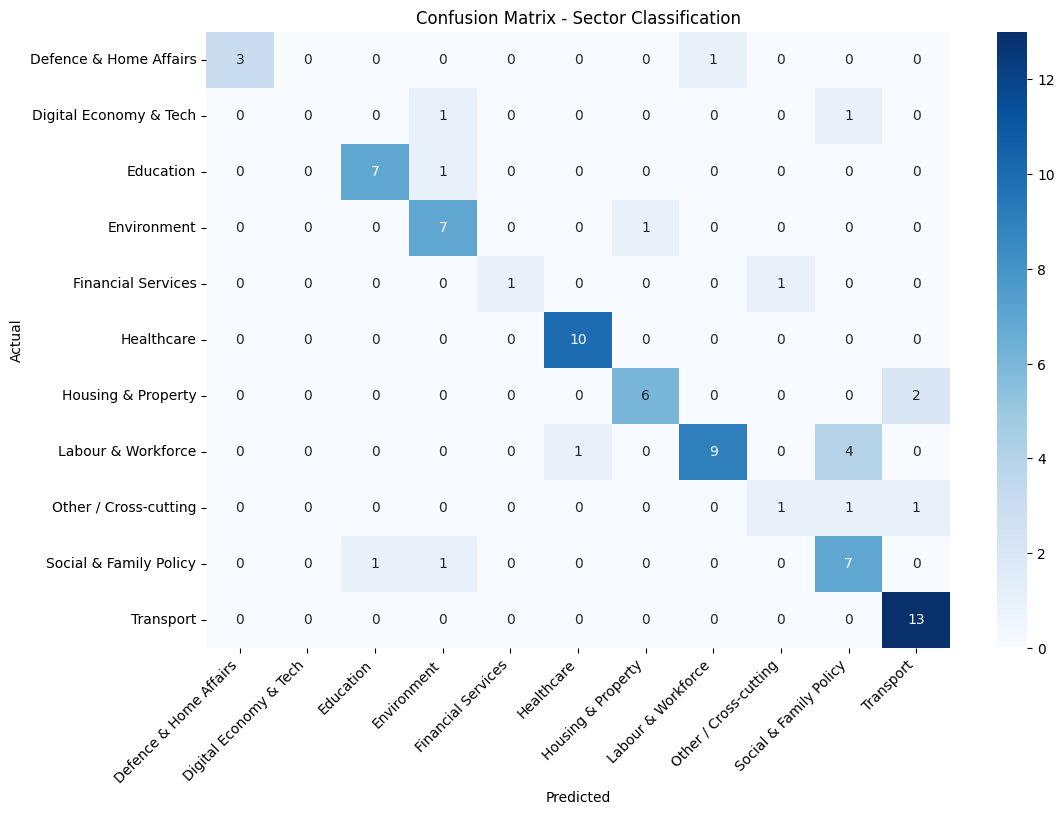

In [ ]:
labels = sorted(df["sector_label"].unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Sector Classification")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_cv_pred = cross_val_predict(sector_clf, X, y, cv=cv)

cv_acc = accuracy_score(y, y_cv_pred)
cv_f1 = f1_score(y, y_cv_pred, average="macro")

print("CV Accuracy:", round(cv_acc, 4))
print("CV Macro F1:", round(cv_f1, 4))
print(classification_report(y, y_cv_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

CV Accuracy: 0.8123
CV Macro F1: 0.7297
                        precision    recall  f1-score   support

Defence & Home Affairs       0.89      0.73      0.80        22
Digital Economy & Tech       0.75      0.60      0.67        10
             Education       0.85      0.85      0.85        40
           Environment       0.76      0.88      0.81        42
    Financial Services       0.50      0.33      0.40         9
            Healthcare       0.82      0.94      0.88        49
    Housing & Property       0.80      0.82      0.81        39
    Labour & Workforce       0.92      0.80      0.85        69
 Other / Cross-cutting       0.40      0.27      0.32        15
Social & Family Policy       0.67      0.74      0.70        43
             Transport       0.91      0.96      0.93        67

              accuracy                           0.81       405
             macro avg       0.75      0.72      0.73       405
          weighted avg       0.81      0.81      0.81       40

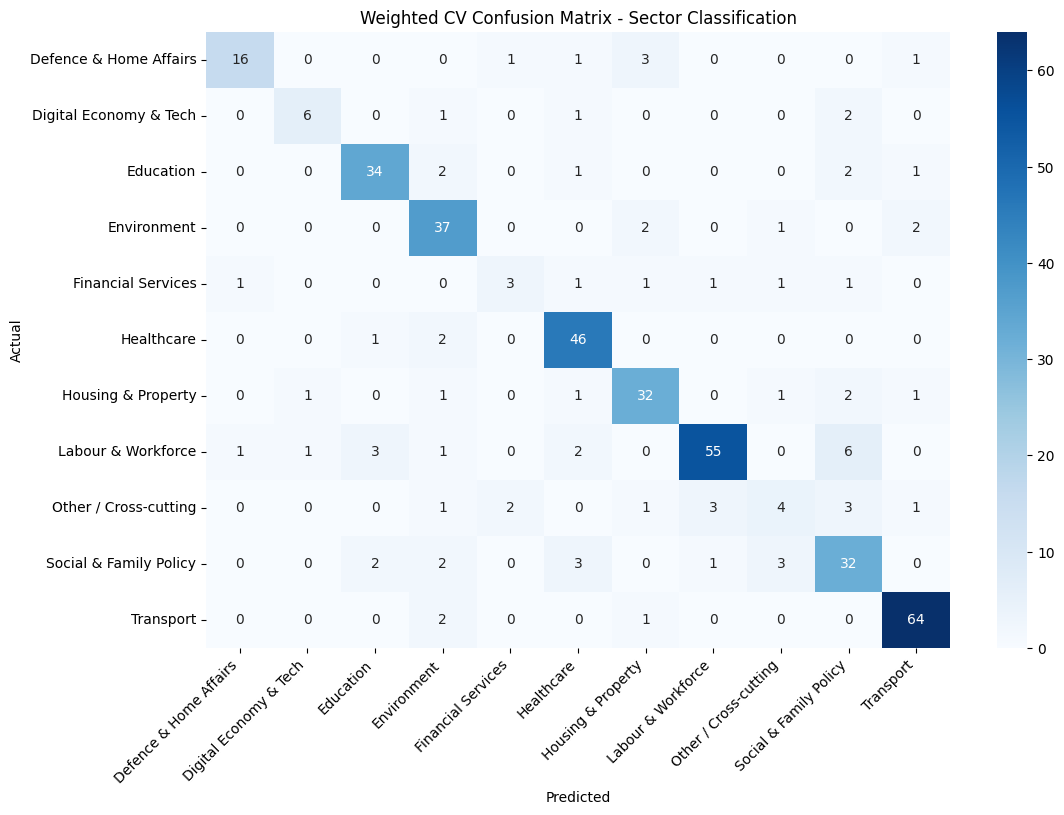

In [21]:
labels = sorted(df["sector_label"].unique())
cm = confusion_matrix(y, y_cv_pred, labels=labels)

plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Weighted CV Confusion Matrix - Sector Classification")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

Use Confidence to Weight

In [ ]:
confidence_map = {
    "HIGH": 1.0,
    "MEDIUM": 0.7,
    "LOW": 0.4
}
df["sample_weight"] = df["confidence"].map(confidence_map).fillna(1.0)

In [ ]:
X = df["combined_text"]
y = df["sector_label"]
w = df["sample_weight"]

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w,
    test_size=0.2,
    random_state=42,
    stratify=y
)

sector_clf.fit(X_train, y_train, clf__sample_weight=w_train)
y_pred = sector_clf.predict(X_test)

print("Weighted Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Weighted Accuracy: 0.7777777777777778
Weighted Macro F1: 0.6382015407093777
                        precision    recall  f1-score   support

Defence & Home Affairs       1.00      0.75      0.86         4
Digital Economy & Tech       0.00      0.00      0.00         2
             Education       0.86      0.75      0.80         8
           Environment       0.70      0.88      0.78         8
    Financial Services       0.50      0.50      0.50         2
            Healthcare       0.91      1.00      0.95        10
    Housing & Property       0.86      0.75      0.80         8
    Labour & Workforce       0.91      0.71      0.80        14
 Other / Cross-cutting       0.00      0.00      0.00         3
Social & Family Policy       0.54      0.78      0.64         9
             Transport       0.81      1.00      0.90        13

              accuracy                           0.78        81
             macro avg       0.64      0.65      0.64        81
          weighted avg    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
confidence_map = {
    "HIGH": 1.0,
    "MEDIUM": 0.7,
    "LOW": 0.4
}

df["sample_weight"] = df["confidence"].map(confidence_map).fillna(1.0)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

X = df["combined_text"].values
y = df["sector_label"].values
w = df["sample_weight"].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_true = []
all_pred = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    w_train = w[train_idx]

    sector_clf.fit(X_train, y_train, clf__sample_weight=w_train)
    y_pred = sector_clf.predict(X_test)

    all_true.extend(y_test)
    all_pred.extend(y_pred)

cv_acc_weighted = accuracy_score(all_true, all_pred)
cv_f1_weighted = f1_score(all_true, all_pred, average="macro")

print("Weighted CV Accuracy:", round(cv_acc_weighted, 4))
print("Weighted CV Macro F1:", round(cv_f1_weighted, 4))
print(classification_report(all_true, all_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Weighted CV Accuracy: 0.8025
Weighted CV Macro F1: 0.6944
                        precision    recall  f1-score   support

Defence & Home Affairs       0.88      0.68      0.77        22
Digital Economy & Tech       0.62      0.50      0.56        10
             Education       0.85      0.85      0.85        40
           Environment       0.73      0.88      0.80        42
    Financial Services       0.50      0.33      0.40         9
            Healthcare       0.82      0.94      0.88        49
    Housing & Property       0.79      0.85      0.81        39
    Labour & Workforce       0.89      0.80      0.84        69
 Other / Cross-cutting       0.20      0.07      0.10        15
Social & Family Policy       0.67      0.74      0.70        43
             Transport       0.91      0.96      0.93        67

              accuracy                           0.80       405
             macro avg       0.71      0.69      0.69       405
          weighted avg       0.79      0.80 

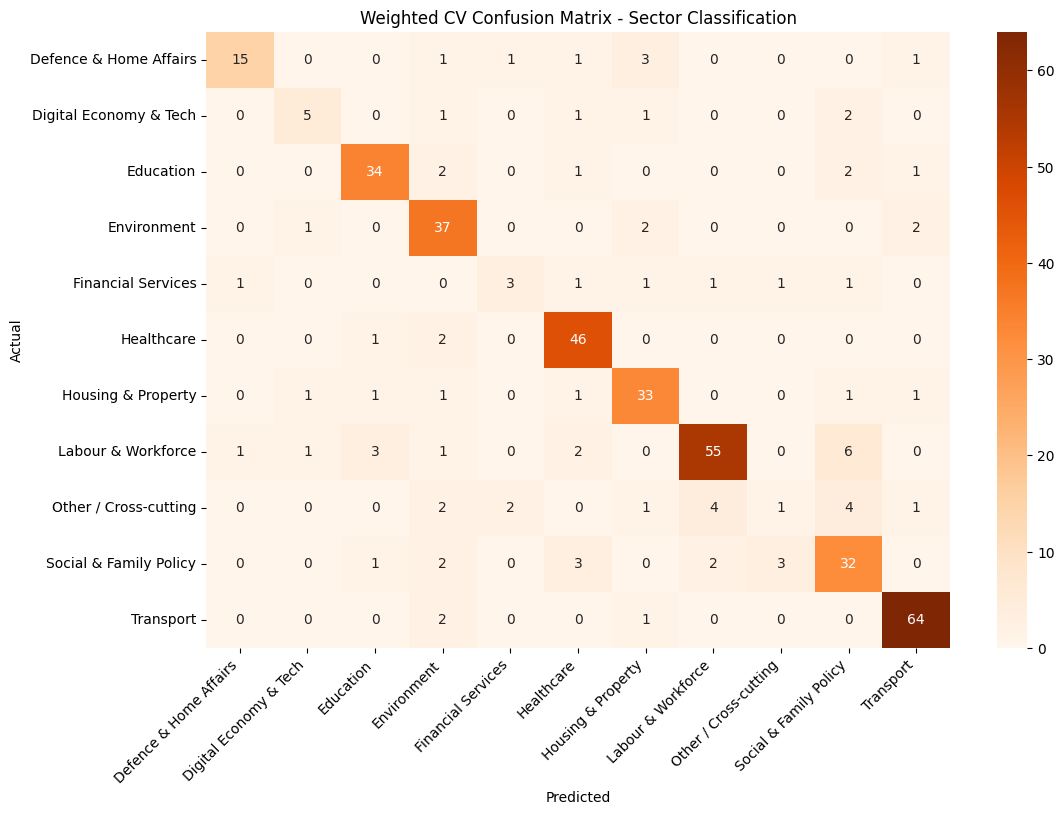

In [ ]:
labels = sorted(df["sector_label"].unique())
cm = confusion_matrix(all_true, all_pred, labels=labels)

plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Weighted CV Confusion Matrix - Sector Classification")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

Use Unweighted Model：

Top Keywords

In [ ]:
vectorizer = sector_clf.named_steps["tfidf"]
clf = sector_clf.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())
classes = clf.classes_

for i, label in enumerate(classes):
    top10 = np.argsort(clf.coef_[i])[-10:]
    print(f"\nTop keywords for {label}:")
    print(", ".join(feature_names[top10]))


Top keywords for Defence & Home Affairs:
minister home, security minister, fires, home affairs, defence, national security, affairs, ica, aid, security

Top keywords for Digital Economy & Tech:
parents, information, imda, digital development, development information, content, media, online, trust, digital

Top keywords for Education:
primary, teaching, student, minister education, teachers, courses, school, schools, education, students

Top keywords for Environment:
sfa, carbon, nea, energy, minister sustainability, sustainability, water, sustainability environment, environment, food

Top keywords for Financial Services:
cpf, fidrec, credit, customers, debt, government, bankruptcy, platform, insurers, claims

Top keywords for Healthcare:
medical, minister social, policies, screening, policies minister, minister health, social policies, healthier, healthcare, health

Top keywords for Housing & Property:
noise, blocks, minister national, development, property, housing, national developm

Error Analysis

In [ ]:
# 把 CV 预测结果和原始数据拼起来
cv_results = df[["debate_id", "title", "turn1", "turn2", "sector_label", "confidence"]].copy()
cv_results["predicted"] = y_cv_pred
cv_results = cv_results.rename(columns={"sector_label": "actual"})

# 取错分案例
cv_errors = cv_results[cv_results["actual"] != cv_results["predicted"]].copy()

print("Total misclassified cases:", len(cv_errors))
cv_errors[["debate_id", "title", "actual", "predicted", "confidence"]].head(15)

Total misclassified cases: 76


,debate_id,title,actual,predicted,confidence
4,D005,Evaluating Risky and Ineffective Airdrops of H...,Defence & Home Affairs,Transport,MEDIUM
12,D013,Extension of Enhanced MRSS for Vulnerable Work...,Labour & Workforce,Social & Family Policy,HIGH
17,D018,Impact on Singapore from Shutdown Affecting Op...,Healthcare,Environment,MEDIUM
25,D026,Measures to Stop Active Mobility Users on Park...,Environment,Transport,HIGH
29,D030,Data on Composition and Distribution of Househ...,Labour & Workforce,Digital Economy & Tech,HIGH
32,D033,Appeals for Additional CDC Vouchers from Diffe...,Social & Family Policy,Other / Cross-cutting,HIGH
37,D038,Cumulative Noise Cap Implementation for Concur...,Other / Cross-cutting,Transport,LOW
41,D042,First Responder Agency for Enforcing Late Nigh...,Defence & Home Affairs,Housing & Property,HIGH
47,D048,Data on Employment of Local Graduates of IHLs ...,Labour & Workforce,Environment,HIGH
50,D051,Criteria for Location of Active Ageing Centres...,Housing & Property,Healthcare,HIGH


In [ ]:
error_pairs = (
    cv_errors.groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_pairs.head(10)

,actual,predicted,count
33,Labour & Workforce,Social & Family Policy,6
44,Social & Family Policy,Other / Cross-cutting,3
2,Defence & Home Affairs,Housing & Property,3
37,Other / Cross-cutting,Labour & Workforce,3
38,Other / Cross-cutting,Social & Family Policy,3
30,Labour & Workforce,Education,3
42,Social & Family Policy,Healthcare,3
21,Healthcare,Environment,2
26,Housing & Property,Social & Family Policy,2
6,Digital Economy & Tech,Social & Family Policy,2


In [ ]:
for _, row in cv_errors.head(5).iterrows():
    print("="*100)
    print("Debate ID:", row["debate_id"])
    print("Title:", row["title"])
    print("Actual:", row["actual"])
    print("Predicted:", row["predicted"])
    print("Confidence:", row["confidence"])
    print("Turn1 snippet:", row["turn1"][:400])
    print("Turn2 snippet:", row["turn2"][:400])

Debate ID: D005
Title: Evaluating Risky and Ineffective Airdrops of Humanitarian Aid to Intended Recipients
Actual: Defence & Home Affairs
Predicted: Transport
Confidence: MEDIUM
Turn1 snippet: asked the Coordinating Minister for Public Services and Minister for Defence whether the Ministry has evaluated the value of conducting airdrops of humanitarian aid, in the light of concerns that such airdrops into the Gaza strip have been ineffective, dangerous and risky to intended recipients.
Turn2 snippet: The preferred and most effective model of humanitarian aid delivery to Gaza is via land transfer. Airdrops, which entail higher risk and cost, are a last resort when land transfer becomes restricted and the humanitarian situation is dire. To reduce the risk to the intended recipients, the Republic of Singapore Air Force (RSAF) worked with the Royal Jordanian Air Force to select suitable drop zones
Debate ID: D013
Title: Extension of Enhanced MRSS for Vulnerable Workers with Career Interrup